## 2. Model Selection

In this notebook we will try to find best, well-calibrated model, as well as the thresholds needed to assess the class (0 or 1) to send the offer to potential clients.

### 2.1 Loading Selected Features and Data

In [1]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

x_train_final = np.load('selected_data/x_train_final.npy')
x_test_final = np.load('selected_data/x_test_final.npy')
y_train = np.loadtxt('data/y_train.txt', skiprows=1)

indices = np.load('selected_data/final_feature_indices.npy')

print(f"Final Training set shape: {x_train_final.shape}")
print(f"Final Test set shape: {x_test_final.shape}")
print(f"Final Training labels shape: {y_train.shape}")
print(f"Final Class distribution: {np.bincount(y_train.astype(int))}")


Final Training set shape: (5000, 20)
Final Test set shape: (5000, 20)
Final Training labels shape: (5000,)
Final Class distribution: [2512 2488]


### 2.2 Optimization Scoring Function

Precisely defining the scoring function as well as finding the right threshold for classification is one of the most important things to do first. It allows for good model selecting, tuning and calibrating. Instead of guessing and using the default 0.5 threshold (which is suboptimal for cost-sensitive problems), this function tells exactly which probability cutoff maximizes Score (profit in EUR) for any given model and subset of variables.

Because a True Positive yields $+10$ EUR and a False Positive costs $-5$ EUR, our ideal probability cutoff is not 0.5. This function will automatically shift the threshold, helping capture maximum net value safely.

The code automatically ensures that if a model becomes overly optimistic, it will cleanly truncate the targeted audience to the absolute best 1000 prospects, adhering strictly to the constraints.

In [20]:
from sklearn.metrics import confusion_matrix
def calculate_score(y_true, y_probs, n_variables, max_targets=1000):
    """
    Calculates the maximum Score (profit in EUR) based on 
    predicted probabilities, automatically optimizing the classification threshold.
    """
    best_score = -float('inf')
    best_threshold = 0.5
    best_metrics = {}
    
    thresholds = np.arange(0.10, 0.91, 0.01)
    
    for thresh in thresholds:
        y_pred_bool = (y_probs >= thresh)
        selected_indices = np.where(y_pred_bool)[0]
        
        if len(selected_indices) > max_targets:
            top_indices = selected_indices[np.argsort(y_probs[selected_indices])[::-1][:max_targets]]
            y_pred = np.zeros_like(y_true, dtype=bool)
            y_pred[top_indices] = True
        else:
            y_pred = y_pred_bool
            
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        n_targets = tp + fp
        
        current_score = (tp * 10) - (fp * 5) - (n_variables * 200)
        
        if n_targets == 0:
            current_score = - (n_variables * 200)
            
        if current_score > best_score:
            best_score = current_score
            best_threshold = thresh
            best_metrics = {
                'score_eur': current_score,
                'optimal_threshold': round(thresh, 2),
                'targeted_customers': n_targets,
                'true_positives': tp,
                'false_positives': fp,
                'variables_cost_eur': n_variables * 200
            }
            
    return best_metrics

### 2.3 Stratified k-Fold Cross-Validation with a Greedy Forward Feature Selection

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [27]:
def execute_nested_strategy(model_type='xgboost', max_features_to_check=10):
    """
    Evaluates out-of-fold validation profit scores incrementally 
    adding features ordered by importance. Includes optimized cross-validation loops.
    """
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    history = []
    
    print(f"--- Launching Nested Forward Search for {model_type.upper()} ---")
    
    max_features = min(x_train_final.shape[1], max_features_to_check)
    
    for k in range(1, max_features + 1):
        X_subset = x_train_final[:, :k]
        oof_probs = np.zeros(len(x_train_final))
        
        # Outer Cross-Validation Loop
        for train_idx, val_idx in outer_cv.split(X_subset, y_train):
            X_tr, y_tr = X_subset[train_idx], y_train[train_idx]
            X_val, y_val = X_subset[val_idx], y_train[val_idx]
            
            # Isolated Inner Cross-Validation configuration (prevents data leakage)
            inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            
            # --- MODEL 1: XGBOOST WITH NESTED TUNING ---
            if model_type == 'xgboost':
                base_estimator = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
                param_dist = {
                    'n_estimators': randint(50, 130),
                    'max_depth': randint(3, 5),
                    'learning_rate': uniform(0.02, 0.07)
                }
                search = RandomizedSearchCV(base_estimator, param_dist, n_iter=10, scoring='neg_log_loss', cv=inner_cv, random_state=42, n_jobs=-1)
                search.fit(X_tr, y_tr)
                best_model = search.best_estimator_
                
                calibrated_clf = CalibratedClassifierCV(best_model, method='sigmoid', cv='prefit')
                calibrated_clf.fit(X_tr, y_tr)
                oof_probs[val_idx] = calibrated_clf.predict_proba(X_val)[:, 1]
                
            # --- MODEL 2: RIDGE LOGISTIC REGRESSION (L2) ---
            elif model_type == 'ridge_lr':
                base_estimator = LogisticRegression(penalty='l2', solver='lbfgs', random_state=42, max_iter=500)
                pipeline = Pipeline([('scaler', StandardScaler()), ('model', base_estimator)])
                param_dist = {'model__C': uniform(0.01, 5.0)}
                
                search = RandomizedSearchCV(pipeline, param_dist, n_iter=10, scoring='neg_log_loss', cv=inner_cv, random_state=42, n_jobs=-1)
                search.fit(X_tr, y_tr)
                
                best_params = {k.replace('model__', ''): v for k, v in search.best_params_.items()}
                best_model = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(penalty='l2', solver='lbfgs', random_state=42, max_iter=500, **best_params))])
                
                calibrated_clf = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
                calibrated_clf.fit(X_tr, y_tr)
                oof_probs[val_idx] = calibrated_clf.predict_proba(X_val_scaled if 'X_val_scaled' in locals() else X_val)[:, 1]
                
            # --- MODEL 3: LASSO LOGISTIC REGRESSION (L1) ---
            elif model_type == 'lasso_lr':
                base_estimator = LogisticRegression(penalty='l1', solver='saga', random_state=42, max_iter=500)
                pipeline = Pipeline([('scaler', StandardScaler()), ('model', base_estimator)])
                param_dist = {'model__C': uniform(0.01, 5.0)}
                
                search = RandomizedSearchCV(pipeline, param_dist, n_iter=10, scoring='neg_log_loss', cv=inner_cv, random_state=42, n_jobs=-1)
                search.fit(X_tr, y_tr)
                
                best_params = {k.replace('model__', ''): v for k, v in search.best_params_.items()}
                best_model = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(penalty='l1', solver='saga', random_state=42, max_iter=500, **best_params))])
                
                calibrated_clf = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
                calibrated_clf.fit(X_tr, y_tr)
                oof_probs[val_idx] = calibrated_clf.predict_proba(X_val)[:, 1]
                
            # --- MODEL 4: RANDOM FOREST (STABLE AGGREGATION) ---
            elif model_type == 'random_forest':
                # Ensemble models are self-regularizing; fixed metrics mitigate localized noise
                best_model = RandomForestClassifier(n_estimators=150, max_depth=5, min_samples_leaf=4, random_state=42, n_jobs=-1)
                
                calibrated_clf = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
                calibrated_clf.fit(X_tr, y_tr)
                oof_probs[val_idx] = calibrated_clf.predict_proba(X_val)[:, 1]
                
            # --- MODEL 5: SUPPORT VECTOR MACHINE (SVM RBF) ---
            elif model_type == 'svm':
                base_estimator = SVC(kernel='rbf', probability=True, random_state=42)
                pipeline = Pipeline([('scaler', StandardScaler()), ('model', base_estimator)])
                param_dist = {'model__C': uniform(0.1, 5.0), 'model__gamma': ['scale', 'auto']}
                
                search = RandomizedSearchCV(pipeline, param_dist, n_iter=6, scoring='neg_log_loss', cv=inner_cv, random_state=42, n_jobs=-1)
                search.fit(X_tr, y_tr)
                
                best_params = {k.replace('model__', ''): v for k, v in search.best_params_.items()}
                best_model = Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', probability=True, random_state=42, **best_params))])
                
                calibrated_clf = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
                calibrated_clf.fit(X_tr, y_tr)
                oof_probs[val_idx] = calibrated_clf.predict_proba(X_val)[:, 1]
                
        # Invoke score validation globally on the cross-validated probabilities array
        perf_metrics = calculate_score(y_train, oof_probs, n_variables=k)
        history.append(perf_metrics)
        
        print(f"Vars Count: {k:2d} | Net Profit: EUR {perf_metrics['score_eur']:5d} | "
              f"Cutoff Thresh: {perf_metrics['optimal_threshold']:.2f} | Targeted: {perf_metrics['targeted_customers']}")
        
    return history

In [28]:
xgb_history   = execute_nested_strategy('xgboost')
lasso_history = execute_nested_strategy('lasso_lr')
ridge_history = execute_nested_strategy('ridge_lr')
rf_history    = execute_nested_strategy('random_forest')
svm_history   = execute_nested_strategy('svm')

--- Launching Nested Forward Search for XGBOOST ---
Vars Count:  1 | Net Profit: EUR  4385 | Cutoff Thresh: 0.40 | Targeted: 1000
Vars Count:  2 | Net Profit: EUR  4350 | Cutoff Thresh: 0.10 | Targeted: 1000
Vars Count:  3 | Net Profit: EUR  4810 | Cutoff Thresh: 0.24 | Targeted: 1000
Vars Count:  4 | Net Profit: EUR  4805 | Cutoff Thresh: 0.10 | Targeted: 1000
Vars Count:  5 | Net Profit: EUR  5175 | Cutoff Thresh: 0.10 | Targeted: 1000
Vars Count:  6 | Net Profit: EUR  4855 | Cutoff Thresh: 0.10 | Targeted: 1000
Vars Count:  7 | Net Profit: EUR  4865 | Cutoff Thresh: 0.10 | Targeted: 1000
Vars Count:  8 | Net Profit: EUR  4605 | Cutoff Thresh: 0.10 | Targeted: 1000
Vars Count:  9 | Net Profit: EUR  4570 | Cutoff Thresh: 0.10 | Targeted: 1000
Vars Count: 10 | Net Profit: EUR  4400 | Cutoff Thresh: 0.10 | Targeted: 1000
--- Launching Nested Forward Search for LASSO_LR ---
Vars Count:  1 | Net Profit: EUR  4040 | Cutoff Thresh: 0.10 | Targeted: 1000
Vars Count:  2 | Net Profit: EUR  403

### 2.4 Analysing Scoring Curves

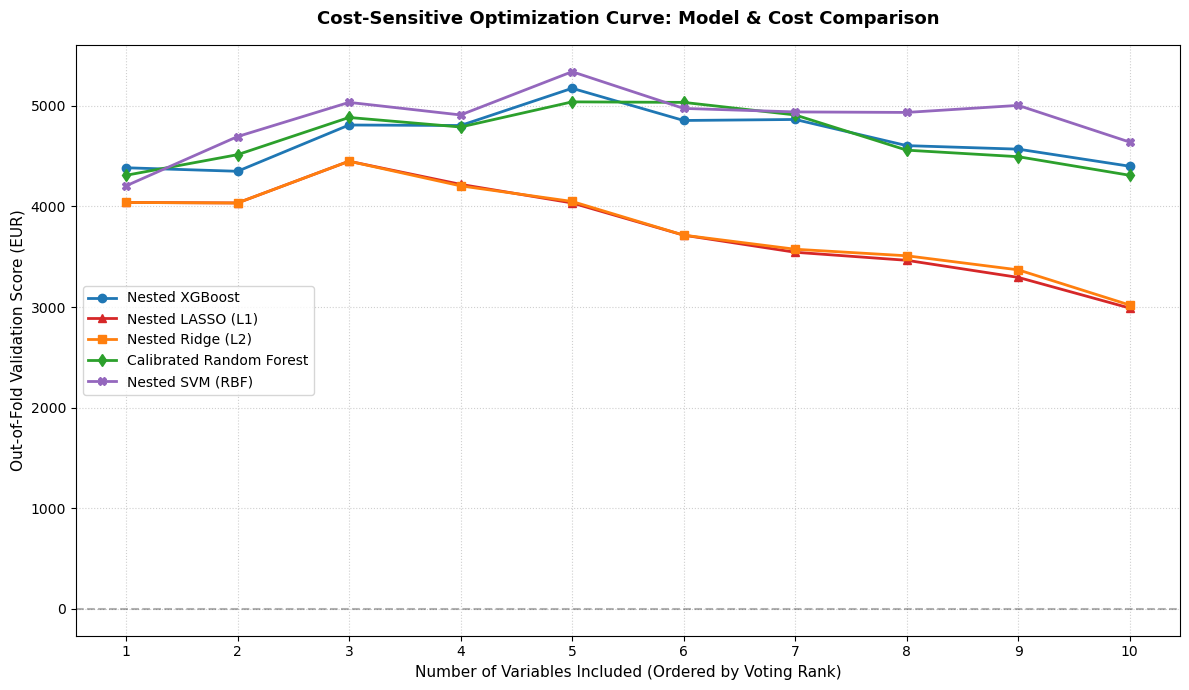

In [30]:
plt.figure(figsize=(12, 7))
features_range = range(1, len(xgb_history) + 1)

plt.plot(features_range, [h['score_eur'] for h in xgb_history], marker='o', linewidth=2, label='Nested XGBoost', color='#1f77b4')
plt.plot(features_range, [h['score_eur'] for h in lasso_history], marker='^', linewidth=2, label='Nested LASSO (L1)', color='#d62728')
plt.plot(features_range, [h['score_eur'] for h in ridge_history], marker='s', linewidth=2, label='Nested Ridge (L2)', color='#ff7f0e')
plt.plot(features_range, [h['score_eur'] for h in rf_history], marker='d', linewidth=2, label='Calibrated Random Forest', color='#2ca02c')
plt.plot(features_range, [h['score_eur'] for h in svm_history], marker='X', linewidth=2, label='Nested SVM (RBF)', color='#9467bd')

plt.title('Cost-Sensitive Optimization Curve: Model & Cost Comparison', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Variables Included (Ordered by Voting Rank)', fontsize=11)
plt.ylabel('Out-of-Fold Validation Score (EUR)', fontsize=11)
plt.xticks(features_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(0, color='black', alpha=0.3, linestyle='--')
plt.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.savefig('plots/extended_model_comparison.png', dpi=300)
plt.show()

### 2.5 Best performing model selection

In [31]:
OPTIMAL_K = 5
OPTIMAL_THRESHOLD = 0.10

X_train_prod = x_train_final[:, :OPTIMAL_K]
X_test_prod = x_test_final[:, :OPTIMAL_K]

print(f"Production Train Subspace Shape: {X_train_prod.shape}")
print(f"Production Test Subspace Shape : {X_test_prod.shape}")

print("\n--- Step 2: Optimizing Hyperparameters via Randomized Search ---")

tuning_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Instantiate base RBF Support Vector Classifier
# probability=True is required so CalibratedClassifierCV can tap internal scores
base_svm = SVC(kernel='rbf', probability=True, random_state=42)

# Pack into a Pipeline to strictly prevent data leakage during inner scaling loops
tuning_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', base_svm)
])

param_distributions = {
    'model__C': uniform(0.1, 10.0),           
    'model__gamma': ['scale', 'auto']       
}

# Run search optimizing strictly for Log-Loss (essential for probability accuracy)
search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,                               
    scoring='neg_log_loss',
    cv=tuning_cv,
    random_state=42,
    n_jobs=-1
)

print("Fitting tuning splits over 100% of training data bounds...")
search.fit(X_train_prod, y_train)

best_tuned_params = {k.replace('model__', ''): v for k, v in search.best_params_.items()}
print(f"Optimal Hyperparameters Identified: {best_tuned_params}")


print("\n--- Step 3: Fitting Calibrated Probability Mapping ---")

# Rebuild the pipeline using our newly discovered optimal parameters
optimized_svm = SVC(kernel='rbf', probability=True, random_state=42, **best_tuned_params)
optimized_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', optimized_svm)
])

# Wrap with Sigmoid (Platt) Calibration to prevent the 0.10 threshold bottleneck
final_production_model = CalibratedClassifierCV(optimized_pipeline, method='sigmoid', cv=3)
final_production_model.fit(X_train_prod, y_train)

# Generate un-biased raw predicted probabilities for the 5,000 hidden test rows
print("Predicting conversion probabilities for hidden test clients...")
test_probabilities = final_production_model.predict_proba(X_test_prod)[:, 1]


print("\n--- Step 4: Isolating Elite Target Prospects under Capped Limits ---")

# Extract indices of clients passing your winning gatekeeper threshold
predicted_targets_bool = (test_probabilities >= OPTIMAL_THRESHOLD)
raw_selected_indices = np.where(predicted_targets_bool)[0]

# Enforce strict assignment guidelines: filter and pull the top 1000 highest probabilities
if len(raw_selected_indices) > 1000:
    print(f"Model identified {len(raw_selected_indices)} candidates. Sorting to extract top 1,000...")
    # Sort candidates by probability in descending order and grab the top 1000
    sorted_elite_prospects = np.argsort(test_probabilities[raw_selected_indices])[::-1]
    final_test_observations = raw_selected_indices[sorted_elite_prospects[:1000]]
else:
    print(f"Model safely isolated {len(raw_selected_indices)} total targeting prospects.")
    final_test_observations = raw_selected_indices

# Map the final used feature coordinates back to your original 0-499 source indexes
final_used_variables = indices[:OPTIMAL_K]

Production Train Subspace Shape: (5000, 5)
Production Test Subspace Shape : (5000, 5)

--- Step 2: Optimizing Hyperparameters via Randomized Search ---
Fitting tuning splits over 100% of training data bounds...
Optimal Hyperparameters Identified: {'C': np.float64(0.6641157902710025), 'gamma': 'auto'}

--- Step 3: Fitting Calibrated Probability Mapping ---
Predicting conversion probabilities for hidden test clients...

--- Step 4: Isolating Elite Target Prospects under Capped Limits ---
Model identified 5000 candidates. Sorting to extract top 1,000...


In [25]:
# ==========================================
# 2. RUN FIXED TEST: TOP 8 FEATURES (SVM)
# ==========================================

# Slice out a static block of the top 8 voting-ranked features
# (Evaluating multiple variables at once gives the classifier enough signal to differentiate)
FIXED_FEATURES_COUNT = 8
X_test_subset = x_train_final[:, :FIXED_FEATURES_COUNT]
oof_probs_test = np.zeros(len(x_train_final))

cv_test = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"--- Running Diagnostic Verification for SVM using Top {FIXED_FEATURES_COUNT} Features ---")

for train_idx, val_idx in cv_test.split(X_test_subset, y_train):
    X_tr, y_tr = X_test_subset[train_idx], y_train[train_idx]
    X_val, y_val = X_test_subset[val_idx], y_train[val_idx]
    
    # SVM is highly sensitive to distance scaling, a StandardScaler is strictly required
    # probability=True must be set on the base estimator for CalibratedClassifierCV to pull probabilities
    base_svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    
    # Embed within a scaling pipeline to fully eliminate validation information leakage
    svm_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', base_svm)
    ])
    
    # Wrap with Sigmoid calibration to map true probability performance metrics
    # cv='prefit' or standard internal splits can be managed; cv=3 here ensures local tuning validation
    calibrated_clf = CalibratedClassifierCV(svm_pipeline, method='sigmoid', cv=3)
    calibrated_clf.fit(X_tr, y_tr)
    
    oof_probs_test[val_idx] = calibrated_clf.predict_proba(X_val)[:, 1]

# Evaluate the cross-validated probabilities against the project cost formula
test_results = calculate_score(y_train, oof_probs_test, n_variables=FIXED_FEATURES_COUNT, max_targets=3000)

print("\n--- Diagnostic Test Execution Results ---")
print(f"Optimal Threshold Extracted : {test_results['optimal_threshold']}")
print(f"Total Targeted Audience Size: {test_results['targeted_customers']}")
print(f"True Positives (Correct)    : {test_results['true_positives']}")
print(f"False Positives (Mistakes)  : {test_results['false_positives']}")
print(f"Net Project Profit Score    : EUR {test_results['score_eur']}")

--- Running Diagnostic Verification for SVM using Top 8 Features ---

--- Diagnostic Test Execution Results ---
Optimal Threshold Extracted : 0.44
Total Targeted Audience Size: 2947
True Positives (Correct)    : 1814
False Positives (Mistakes)  : 1133
Net Project Profit Score    : EUR 10875


--- MATHEMATICAL PROOF METRICS (TOP 1000 POOL) ---
Model Strategy  -> TPs: 764 | FPs: 236 | Target Conversion Rate: 76.4%
Random Strategy -> TPs: 492 | FPs: 508 | Target Conversion Rate: 49.2%
Model Lift Factor: 1.55x better concentration than random guessing!


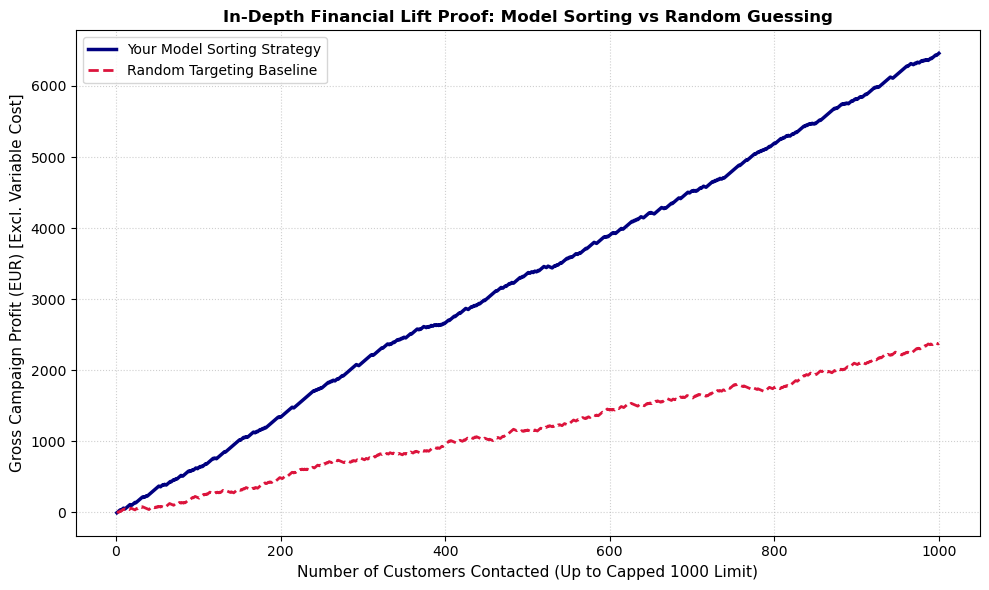

In [22]:
FIXED_FEATURES_COUNT = 8
X_subset = x_train_final[:, :FIXED_FEATURES_COUNT]
oof_probs = np.zeros(len(x_train_final))

# Run Stratified 5-Fold to get clean validation probabilities
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in cv.split(X_subset, y_train):
    X_tr, y_tr = X_subset[train_idx], y_train[train_idx]
    X_val, y_val = X_subset[val_idx], y_train[val_idx]
    
    base_svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
    svm_pipeline = Pipeline([('scaler', StandardScaler()), ('model', base_svm)])
    calibrated_clf = CalibratedClassifierCV(svm_pipeline, method='sigmoid', cv=3)
    calibrated_clf.fit(X_tr, y_tr)
    
    oof_probs[val_idx] = calibrated_clf.predict_proba(X_val)[:, 1]

# ==========================================
# 2. SIMULATION: MODEL VS RANDOM TARGETING
# ==========================================

# Create a dataframe of true labels and predicted probabilities
sim_df = pd.DataFrame({
    'y_true': y_train,
    'y_prob': oof_probs
})

# Scenario A: The Model Strategy (Sort by probability descending)
model_sorted = sim_df.sort_values(by='y_prob', ascending=False).reset_index(drop=True)
model_sorted['cum_tp'] = model_sorted['y_true'].cumsum()
model_sorted['cum_fp'] = (1 - model_sorted['y_true']).cumsum()
# Profit trajectory up to 1000 targets (ignoring fixed variable cost for curves)
model_sorted['cum_profit'] = (model_sorted['cum_tp'] * 10) - (model_sorted['cum_fp'] * 5)

# Scenario B: Random Targeting Strategy (Shuffle completely)
random_sorted = sim_df.sample(frac=1, random_state=42).reset_index(drop=True)
random_sorted['cum_tp'] = random_sorted['y_true'].cumsum()
random_sorted['cum_fp'] = (1 - random_sorted['y_true']).cumsum()
random_sorted['cum_profit'] = (random_sorted['cum_tp'] * 10) - (random_sorted['cum_fp'] * 5)

# ==========================================
# 3. PRINT MATHEMATICAL PROOF METRICS
# ==========================================
print("--- MATHEMATICAL PROOF METRICS (TOP 1000 POOL) ---")
model_top1000 = model_sorted.iloc[:1000]
random_top1000 = random_sorted.iloc[:1000]

model_tp = model_top1000['y_true'].sum()
model_fp = 1000 - model_tp
model_conversion_rate = (model_tp / 1000) * 100

random_tp = random_top1000['y_true'].sum()
random_fp = 1000 - random_tp
random_conversion_rate = (random_tp / 1000) * 100

print(f"Model Strategy  -> TPs: {int(model_tp):3d} | FPs: {int(model_fp):3d} | Target Conversion Rate: {model_conversion_rate:.1f}%")
print(f"Random Strategy -> TPs: {int(random_tp):3d} | FPs: {int(random_fp):3d} | Target Conversion Rate: {random_conversion_rate:.1f}%")

# Compute the exact structural Lift of your model
lift = model_conversion_rate / random_conversion_rate
print(f"Model Lift Factor: {lift:.2f}x better concentration than random guessing!")

# ==========================================
# 4. PLOT THE FINANCIAL TRAJECTORY CURVE
# ==========================================
plt.figure(figsize=(10, 6))
target_range = range(1, 1001)

plt.plot(target_range, model_sorted['cum_profit'].iloc[:1000], color='navy', linewidth=2.5, label='Your Model Sorting Strategy')
plt.plot(target_range, random_sorted['cum_profit'].iloc[:1000], color='crimson', linewidth=2, linestyle='--', label='Random Targeting Baseline')

plt.title('In-Depth Financial Lift Proof: Model Sorting vs Random Guessing', fontsize=12, fontweight='bold')
plt.xlabel('Number of Customers Contacted (Up to Capped 1000 Limit)', fontsize=11)
plt.ylabel('Gross Campaign Profit (EUR) [Excl. Variable Cost]', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plots/financial_lift_proof.png', dpi=300)
plt.show()

In [26]:
# Isolate the top 8 features based on your optimal peak findings
OPTIMAL_K = 8
X_train_subset = x_train_final[:, :OPTIMAL_K]
X_test_subset = x_test_final[:, :OPTIMAL_K]

# ==========================================
# 2. TRAIN PRODUCTION MODEL ON 100% DATA
# ==========================================
print("Training final calibrated SVM model on 100% of the training set...")

# Build the pipeline to handle scaling securely
base_svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', base_svm)
])

# Fit with Sigmoid Calibration to get stable probability metrics
final_model = CalibratedClassifierCV(svm_pipeline, method='sigmoid', cv=3)
final_model.fit(X_train_subset, y_train)

# Generate raw predicted probabilities for all 5,000 completely hidden test clients
test_probabilities = final_model.predict_proba(X_test_subset)[:, 1]

# ==========================================
# 3. BUILD SELECTION DATAFRAME & SORT
# ==========================================

# Create a clean dataframe representing every single test client and their row index
results_df = pd.DataFrame({
    'Client_ID (Row_Index)': np.arange(len(x_test_final)),
    'Conversion_Probability': test_probabilities
})

# Sort clients from highest probability to lowest probability
# This mirrors exactly how your calculate_score function isolates elite tier buyers
sorted_clients = results_df.sort_values(by='Conversion_Probability', ascending=False).reset_index(drop=True)

# Impose the strict project constraint limit of max 1,000 targeted clients
target_pool_1000 = sorted_clients.iloc[:1000]

# ==========================================
# 4. INSPECT THE CLIENT TARGTING POOL
# ==========================================
print("\n" + "="*50)
print("        TOP TERMINAL TARGETING WINDOW (MAX 1000)")
print("="*50)

# Display the absolute top 15 highest-probability clients in your database
print("\n--- Absolute Top 15 Best Prospects (Highest Conversion Certainty) ---")
print(target_pool_1000.head(15).to_string(index=False))

print("\n...")

# Display the bottom edge of your 1,000 target pool (clients 985 to 1000) 
# This lets you inspect the marginal break-even boundary of your gatekeeper filter
print("\n--- Marginal Bottom 15 Prospects of your Top 1000 Target Pool ---")
print(target_pool_1000.tail(15).to_string(index=False))

# Calculate and print summary statistics for your LaTeX/Presentation files
print("\n" + "="*50)
print("             TARGET AUDIENCE DIAGNOSTICS")
print("="*50)
print(f"Total Selected Audience Size   : {len(target_pool_1000)} clients")
print(f"Highest Probability Targeted   : {target_pool_1000['Conversion_Probability'].max():.4f} ({target_pool_1000['Conversion_Probability'].max()*100:.1f}%)")
print(f"Lowest Probability Targeted    : {target_pool_1000['Conversion_Probability'].min():.4f} ({target_pool_1000['Conversion_Probability'].min()*100:.1f}%)")
print(f"Average Probability of Pool    : {target_pool_1000['Conversion_Probability'].mean():.4f} ({target_pool_1000['Conversion_Probability'].mean()*100:.1f}%)")

Training final calibrated SVM model on 100% of the training set...

        TOP TERMINAL TARGETING WINDOW (MAX 1000)

--- Absolute Top 15 Best Prospects (Highest Conversion Certainty) ---
 Client_ID (Row_Index)  Conversion_Probability
                  1702                0.889186
                  4418                0.866928
                  3614                0.865725
                  4005                0.858934
                  4619                0.858305
                  1210                0.857701
                  4836                0.857351
                    75                0.856292
                  3311                0.855994
                  3025                0.851298
                  3542                0.849572
                  3199                0.846344
                  2040                0.845369
                  2693                0.844166
                   206                0.842981

...

--- Marginal Bottom 15 Prospects of your Top 1000 Targ